# 02 BALL DRIBBLING


In [1]:
import math
import time
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Fijar semilla para garantizar reproducibilidad de los experimentos
np.random.seed(42)
print("Bibliotecas inicializadas correctamente.")

Bibliotecas inicializadas correctamente.


In [68]:
from IPython.display import clear_output, display


def train_visual(
    env,
    algorithm,
    n_episodes=2000,
    render_every=100,
    gamma=0.99,
    alpha=0.1,
    epsilon=0.1,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.998,
    eps_flag=1,
):
    """Entrena MC, SARSA, Expected SARSA o Q-Learning y muestra el progreso."""
    algorithm = algorithm.lower().replace("-", "_").replace(" ", "_")
    if algorithm == "qlearning":
        algorithm = "q_learning"
    if algorithm not in ("mc", "sarsa", "expected_sarsa", "q_learning"):
        raise ValueError("algorithm debe ser mc, sarsa, expected_sarsa o q_learning")
    if render_every < 1:
        raise ValueError("render_every debe ser positivo")

    label = {
        "mc": "Monte Carlo",
        "sarsa": "SARSA",
        "expected_sarsa": "Expected SARSA",
        "q_learning": "Q-Learning",
    }[algorithm]
    n_actions = 4
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    if algorithm == "mc":
        returns_sum = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
        returns_count = defaultdict(lambda: np.zeros(n_actions, dtype=np.int32))
    history_rewards, history_lengths = [], []

    for ep in range(n_episodes):
        eps = (
            max(eps_min, eps_start * eps_decay**ep)
            if algorithm == "mc" and eps_flag
            else epsilon
        )
        state = env.reset()
        episode = [] if algorithm == "mc" else None
        total_reward = 0.0
        steps = 0
        if algorithm == "sarsa":
            action = epsilon_greedy_policy(Q, state, n_actions, eps)

        while True:
            if algorithm != "sarsa":
                action = epsilon_greedy_policy(Q, state, n_actions, eps)
            next_state, reward, done, info = env.step(action)
            total_reward += reward
            steps += 1

            if algorithm == "mc":
                episode.append((state, action, reward))
            else:
                if done:
                    target = reward
                elif algorithm == "sarsa":
                    next_action = epsilon_greedy_policy(Q, next_state, n_actions, eps)
                    target = reward + gamma * Q[next_state][next_action]
                elif algorithm == "expected_sarsa":
                    next_q = Q[next_state]
                    expected_q = eps * next_q.mean() + (1 - eps) * next_q.max()
                    target = reward + gamma * expected_q
                else:
                    target = reward + gamma * Q[next_state].max()
                Q[state][action] += alpha * (target - Q[state][action])

            if done:
                break
            state = next_state
            if algorithm == "sarsa":
                action = next_action

        if algorithm == "mc":
            ep_return = update_first_visit_mc(
                episode, gamma, returns_sum, returns_count, Q
            )
        else:
            ep_return = total_reward
        history_rewards.append(ep_return)
        history_lengths.append(steps)

        # Renderizado en vivo cada render_every episodios
        if ep == 0 or (ep + 1) % render_every == 0 or ep + 1 == n_episodes:
            clear_output(wait=True)
            fig = plt.figure(figsize=(15, 5))
            gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1.0])

            # 1. Cancha de futbol con la trayectoria del episodio actual
            ax_pitch = fig.add_subplot(gs[:, 0])
            ax_pitch.set_facecolor("#2e7d32")
            pitch_border = patches.Rectangle(
                (-52.5, -34),
                105,
                68,
                linewidth=1.8,
                edgecolor="white",
                facecolor="none",
            )
            half_line = plt.Line2D([0, 0], [-34, 34], color="white", linewidth=1.8)
            center_circle = patches.Circle(
                (0, 0), 9.15, linewidth=1.8, edgecolor="white", facecolor="none"
            )
            center_spot = patches.Circle((0, 0), 0.5, color="white")
            left_box = patches.Rectangle(
                (-52.5, -20.16),
                16.5,
                40.32,
                linewidth=1.2,
                edgecolor="white",
                facecolor="none",
            )
            right_box = patches.Rectangle(
                (36.0, -20.16),
                16.5,
                40.32,
                linewidth=1.2,
                edgecolor="white",
                facecolor="none",
            )
            left_goal = patches.Rectangle(
                (-54.5, -7.0),
                2.0,
                14.0,
                linewidth=1.5,
                edgecolor="yellow",
                facecolor="#ffffff",
                alpha=0.3,
            )
            right_goal = patches.Rectangle(
                (52.5, -7.0),
                2.0,
                14.0,
                linewidth=1.5,
                edgecolor="yellow",
                facecolor="#ffffff",
                alpha=0.3,
            )

            ax_pitch.add_patch(pitch_border)
            ax_pitch.add_line(half_line)
            ax_pitch.add_patch(center_circle)
            ax_pitch.add_patch(center_spot)
            ax_pitch.add_patch(left_box)
            ax_pitch.add_patch(right_box)
            ax_pitch.add_patch(left_goal)
            ax_pitch.add_patch(right_goal)
            ax_pitch.plot(
                env.goal_x,
                env.goal_y,
                "*",
                markersize=13,
                color="#ffca28",
                markeredgecolor="black",
                label="Centro de la porteria rival",
            )

            # Trayectoria del jugador
            traj_color = "#00e676" if info["success"] else "#ff9100"
            ax_pitch.plot(
                env.player_trajectory_x,
                env.player_trajectory_y,
                "-o",
                color=traj_color,
                markersize=3,
                linewidth=1.8,
                alpha=0.85,
                label="Trayectoria del Jugador",
            )
            ax_pitch.plot(
                env.player_trajectory_x[0],
                env.player_trajectory_y[0],
                "s",
                markersize=8,
                color="#29b6f6",
                label="Inicio Jugador",
            )
            ax_pitch.plot(
                env.player_x,
                env.player_y,
                "^",
                markersize=10,
                color="#1565c0",
                label="Posicion Final",
            )
            ax_pitch.plot(
                env.ball_trajectory_x,
                env.ball_trajectory_y,
                "-o",
                color="#ffca28",
                markersize=3,
                linewidth=1.8,
                alpha=0.85,
                label="Trayectoria del balon",
            )
            ax_pitch.plot(
                env.ball_trajectory_x[0],
                env.ball_trajectory_y[0],
                "s",
                markersize=7,
                color="white",
                markeredgecolor="black",
                label="Inicio balon",
            )
            ax_pitch.plot(
                env.ball_x,
                env.ball_y,
                "o",
                markersize=10,
                color="#ffca28",
                markeredgecolor="black",
                markeredgewidth=1.8,
                label="Posicion final del balon",
            )

            # Orientacion del jugador
            rad = math.radians(env.player_theta)
            ax_pitch.arrow(
                env.player_x,
                env.player_y,
                1.8 * math.cos(rad),
                1.8 * math.sin(rad),
                head_width=1.0,
                head_length=0.8,
                fc="yellow",
                ec="yellow",
            )

            ax_pitch.set_xlim(-55, 55)
            ax_pitch.set_ylim(-35, 35)
            status_txt = "DRIBLE COMPLETADO" if info["success"] else "SIN EXITO"
            ax_pitch.set_title(
                f"{label} | Episodio {ep+1}/{n_episodes} | {status_txt} ({steps} pasos)",
                fontsize=11,
                fontweight="bold",
            )
            ax_pitch.legend(loc="upper left", fontsize=8, framealpha=0.9)

            # 2. Curva de Retorno en Vivo
            ax_ret = fig.add_subplot(gs[0, 1])
            window = min(30, len(history_rewards))
            ma_r = np.convolve(history_rewards, np.ones(window) / window, mode="valid")
            ax_ret.plot(history_rewards, alpha=0.15, color="#1f77b4")
            ax_ret.plot(
                range(window - 1, len(history_rewards)),
                ma_r,
                color="#1f77b4",
                linewidth=2.0,
                label="Media Movil",
            )
            ax_ret.set_title(
                (
                    "Retorno Acumulado G_0"
                    if algorithm == "mc"
                    else "Recompensa acumulada"
                ),
                fontsize=10,
                fontweight="bold",
            )
            ax_ret.set_xlabel("Episodio", fontsize=9)
            ax_ret.grid(True, alpha=0.3, linestyle=":")
            ax_ret.legend(loc="lower right", fontsize=8)

            # 3. Curva de Pasos en Vivo
            ax_len = fig.add_subplot(gs[1, 1])
            ma_l = np.convolve(history_lengths, np.ones(window) / window, mode="valid")
            ax_len.plot(history_lengths, alpha=0.15, color="#d62728")
            ax_len.plot(
                range(window - 1, len(history_lengths)),
                ma_l,
                color="#d62728",
                linewidth=2.0,
                label="Pasos Necesarios",
            )
            ax_len.set_title("Pasos por Episodio", fontsize=10, fontweight="bold")
            ax_len.set_xlabel("Episodio", fontsize=9)
            ax_len.grid(True, alpha=0.3, linestyle=":")
            ax_len.legend(loc="upper right", fontsize=8)

            plt.tight_layout()
            display(fig)
            plt.close(fig)

    return Q, history_rewards, history_lengths

## 1. Formalizacion del Proceso de Decision de Markov (MDP)

La tarea consiste en conducir el balon mas de 30 m hacia la porteria rival mediante micro-pateos y carreras cortas, sin perder posesion ni salir de la cancha. Se modela mediante la tupla $\langle S,A,P,R,\gamma\rangle$:

- **Estado observado:** $(d_b,\theta_b,d_g,\theta_g)$: distancia y angulo del balon y de la meta, medidos desde el jugador y respecto a su orientacion.
- **Estado discretizado:** $d_b$ tiene 4 zonas con cortes en 0.8, 1.2 y 2 m; $d_g$ tiene 4 zonas con cortes en 50, 60 y 70 m; cada angulo tiene 5 sectores (frente, derecha frontal, izquierda frontal, posterior derecho y posterior izquierdo). Son $4\times5\times4\times5=400$ estados y $400\times4=1600$ pares estado-accion. La discretizacion aproxima el MDP porque oculta diferencias dentro de cada zona.
- **Acciones:** `0=KICK 25` (balon +0.7 m si esta a $\leq0.8$ m), `1=DASH 80` (jugador +0.8 m), `2=TURN +35` y `3=TURN -35`. No se modela inercia.
- **Transicion:** el pateo mueve solo el balon; la carrera mueve solo al jugador; el giro cambia solo su orientacion. El inicio del episodio es aleatorio.
- **Recompensa:** $5(d^{balon\to meta}_{g,t}-d^{balon\to meta}_{g,t+1})-0.2$ por paso, con $-2$ por pateo invalido, $+100$ por exito, $-30$ por perdida de posesion, $-50$ por salida y $-20$ por agotar pasos. El avance recompensado se mide desde el **balon** a la meta, aunque $d_g$ del estado se observa desde el jugador.
- **Descuento:** $\gamma=0.99$ en `train_visual`.

El balon es **pateable** a $d_b\leq0.8$ m y se conserva la **posesion** mientras $d_b\leq2$ m. El episodio termina al superar 30 m de avance del balon con posesion, perderla, salir de la cancha o llegar a 120 pasos. El indicador de exito solo cuenta la conduccion de **mas de** 30 m sin perder posesion; el objetivo del enunciado es lograrlo en mas del 80 % de los episodios.


In [73]:
class BallDribblingSimEnv:
    """Entorno cinematico de conduccion de balon, sin inercia."""

    def __init__(
        self,
        max_steps=120,
        control_threshold=0.8,
        lost_threshold=2.0,
        target_distance=30.0,
    ):
        if max_steps < 1 or not (0 < control_threshold < 1.2 < lost_threshold):
            raise ValueError(
                "Se requiere max_steps positivo y 0 < control < 1.2 < perdida"
            )
        self.max_steps = max_steps
        self.control_threshold = control_threshold
        self.lost_threshold = lost_threshold
        self.target_distance = target_distance
        self.goal_x, self.goal_y = 52.5, 0.0
        self.reset()

    def reset(self):
        self.player_x = np.random.uniform(-30.0, -20.0)
        self.player_y = np.random.uniform(-8.0, 8.0)
        self.player_theta = np.random.uniform(-20.0, 20.0)

        initial_ball_distance = np.random.uniform(0.4, 0.7)
        rad = math.radians(self.player_theta)
        self.ball_x = self.player_x + initial_ball_distance * math.cos(rad)
        self.ball_y = self.player_y + initial_ball_distance * math.sin(rad)
        self.ball_start_x = self.ball_x
        self.steps = 0

        self.player_trajectory_x = [self.player_x]
        self.player_trajectory_y = [self.player_y]
        self.ball_trajectory_x = [self.ball_x]
        self.ball_trajectory_y = [self.ball_y]
        return self._get_state()

    def _relative_polar(self, object_x, object_y):
        dx = object_x - self.player_x
        dy = object_y - self.player_y
        dist = math.hypot(dx, dy)
        global_angle = math.degrees(math.atan2(dy, dx))
        relative_angle = (global_angle - self.player_theta + 180.0) % 360.0 - 180.0
        return dist, relative_angle

    def _get_obs(self):
        d_ball, angle_ball = self._relative_polar(self.ball_x, self.ball_y)
        d_goal, angle_goal = self._relative_polar(self.goal_x, self.goal_y)
        return d_ball, angle_ball, d_goal, angle_goal

    def _distance_ball_bin(self, dist):
        if dist <= self.control_threshold:
            return 0  # Pateable
        if dist <= 1.2:
            return 1  # Cerca
        if dist <= self.lost_threshold:
            return 2  # Recuperable sin perder posesion
        return 3  # Posesion perdida

    def _distance_goal_bin(self, dist):
        if dist < 50.0:
            return 0
        if dist < 60.0:
            return 1
        if dist < 70.0:
            return 2
        return 3

    def _angle_bin(self, angle):
        angle = (angle + 180.0) % 360.0 - 180.0
        if abs(angle) <= 15.0:
            return 0  # Frente
        if -60.0 <= angle < -15.0:
            return 1  # Derecha frontal
        if 15.0 < angle <= 60.0:
            return 2  # Izquierda frontal
        if angle < -60.0:
            return 3  # Posterior derecho
        return 4  # Posterior izquierdo

    def _discretize(self, d_ball, angle_ball, d_goal, angle_goal):
        return (
            self._distance_ball_bin(d_ball),
            self._angle_bin(angle_ball),
            self._distance_goal_bin(d_goal),
            self._angle_bin(angle_goal),
        )

    def _get_state(self):
        return self._discretize(*self._get_obs())

    def step(self, action):
        if action not in (0, 1, 2, 3):
            raise ValueError(f"Accion invalida: {action}")

        self.steps += 1
        d_ball_prev, _, _, _ = self._get_obs()
        old_ball_goal_distance = math.hypot(
            self.goal_x - self.ball_x, self.goal_y - self.ball_y
        )
        invalid_kick = action == 0 and d_ball_prev > self.control_threshold
        rad = math.radians(self.player_theta)

        if action == 0 and not invalid_kick:
            self.ball_x += 0.7 * math.cos(rad)
            self.ball_y += 0.7 * math.sin(rad)
        elif action == 1:
            self.player_x += 0.8 * math.cos(rad)
            self.player_y += 0.8 * math.sin(rad)
        elif action == 2:
            self.player_theta = (self.player_theta + 35.0 + 180.0) % 360.0 - 180.0
        elif action == 3:
            self.player_theta = (self.player_theta - 35.0 + 180.0) % 360.0 - 180.0

        self.player_trajectory_x.append(self.player_x)
        self.player_trajectory_y.append(self.player_y)
        self.ball_trajectory_x.append(self.ball_x)
        self.ball_trajectory_y.append(self.ball_y)

        d_ball, angle_ball, d_goal, angle_goal = self._get_obs()
        progress = self.ball_x - self.ball_start_x
        possession = d_ball <= self.lost_threshold
        ball_out = abs(self.ball_x) > 52.5 or abs(self.ball_y) > 34.0
        player_out = abs(self.player_x) > 52.5 or abs(self.player_y) > 34.0
        out = ball_out or player_out
        success = progress > self.target_distance and possession and not out
        timeout = self.steps >= self.max_steps
        done = success or not possession or out or timeout

        new_ball_goal_distance = math.hypot(
            self.goal_x - self.ball_x, self.goal_y - self.ball_y
        )
        reward = 5.0 * (old_ball_goal_distance - new_ball_goal_distance) - 0.2
        if invalid_kick:
            reward -= 2.0
        if success:
            reward += 100.0
        elif out:
            reward -= 50.0
        elif not possession:
            reward -= 30.0
        elif timeout:
            reward -= 20.0

        info = {
            "ball_dist": d_ball,
            "ball_angle": angle_ball,
            "goal_dist": d_goal,
            "goal_angle": angle_goal,
            "progress": progress,
            "success": success,
            "has_control": d_ball <= self.control_threshold,
            "possession": possession,
            "invalid_kick": invalid_kick,
        }
        return (
            self._discretize(d_ball, angle_ball, d_goal, angle_goal),
            reward,
            done,
            info,
        )


print("Clase BallDribblingSimEnv definida correctamente.")

Clase BallDribblingSimEnv definida correctamente.


## 2. Implementación de Monte Carlo Control On-Policy (First-Visit)

El algoritmo genera cada episodio con una política ε-greedy. Después calcula los retornos descontados $G_t$ desde el final hacia el inicio, pero **actualiza Q recorriendo el episodio desde el inicio**: así utiliza la primera aparición temporal de cada par $(s,a)$. La curva de retorno registra $G_0$, no la suma sin descuento.

La exploración disminuye geométricamente hasta un mínimo de 0,05.


In [74]:
def epsilon_greedy_policy(Q, state, n_actions, eps):
    """Política epsilon-greedy para selección de acciones."""

    if np.random.random() < eps:
        action = np.random.randint(n_actions)
    else:
        q_vals = Q[state]
        if q_vals[0] == q_vals[1] == q_vals[2] == q_vals[3]:
            action = np.random.randint(n_actions)
        else:
            action = int(np.argmax(q_vals))

    return action


def update_first_visit_mc(episode, gamma, returns_sum, returns_count, Q):
    """Calcula G_t hacia atrás y actualiza la primera visita en orden temporal."""
    returns = [0.0] * len(episode)
    G = 0.0
    for t in range(len(episode) - 1, -1, -1):
        G = episode[t][2] + gamma * G
        returns[t] = G

    visited = set()
    for (state, action, _), G in zip(episode, returns):
        if (state, action) in visited:
            continue
        visited.add((state, action))
        returns_sum[state][action] += G
        returns_count[state][action] += 1
        Q[state][action] = returns_sum[state][action] / returns_count[state][action]
    return returns[0]

In [75]:
def train_mc_control(
    env,
    n_episodes=3500,
    gamma=0.99,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.998,
    eps_flag=1,
    eps_var=0.1,
):
    """
    Ejecuta el entrenamiento de Monte Carlo Control On-Policy con First-Visit y epsilon-greedy con e-decay.
    """
    n_actions = 4
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    returns_sum = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    returns_count = defaultdict(lambda: np.zeros(n_actions, dtype=np.int32))

    history_rewards = []
    history_lengths = []

    for ep in range(n_episodes):
        if eps_flag:
            eps = max(eps_min, eps_start * (eps_decay**ep))
        else:
            eps = eps_var

        state = env.reset()
        episode = []

        # 1. Generar trayectoria completa con politica epsilon-greedy
        while True:
            action = epsilon_greedy_policy(Q, state, n_actions, eps)

            next_state, reward, done, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if done:
                break

        # 2. Recorrido retrospectivo para computar retornos (First-Visit)
        G0 = update_first_visit_mc(episode, gamma, returns_sum, returns_count, Q)

        history_rewards.append(G0)
        history_lengths.append(len(episode))

    return Q, history_rewards, history_lengths


# Ejecutar entrenamiento
env_train = BallDribblingSimEnv(
    max_steps=120, control_threshold=0.8, lost_threshold=2.0, target_distance=30.0
)
t_inicio = time.time()
Q_opt, hist_rewards, hist_lengths = train_mc_control(
    env_train, n_episodes=3500, eps_flag=1
)
duracion = time.time() - t_inicio


print(f"Entrenamiento finalizado en {duracion:.2f} segundos.")
print(f"Pasos promedio ultimos 100 episodios: {np.mean(hist_lengths[-100:]):.2f}")
print(f"Retorno promedio ultimos 100 episodios: {np.mean(hist_rewards[-100:]):.2f}")

Entrenamiento finalizado en 5.03 segundos.
Pasos promedio ultimos 100 episodios: 98.63
Retorno promedio ultimos 100 episodios: 90.43


## 2.1 Visualizacion del Entrenamiento en Tiempo Real

La siguiente funcion entrena el agente con Monte Carlo Control mientras renderiza dinamicamente en pantalla:

- **Panel Izquierdo:** La cancha de futbol 2D con la trayectoria, posicion y orientacion del jugador durante el episodio.
- **Panel Derecho Superior:** Evolucion del retorno acumulado por episodio.
- **Panel Derecho Inferior:** Numero de pasos requeridos para interceptar el balon.

La visualización permite comprobar si el agente aprende a avanzar hacia el balón; el entrenamiento no garantiza una captura en todos los episodios.


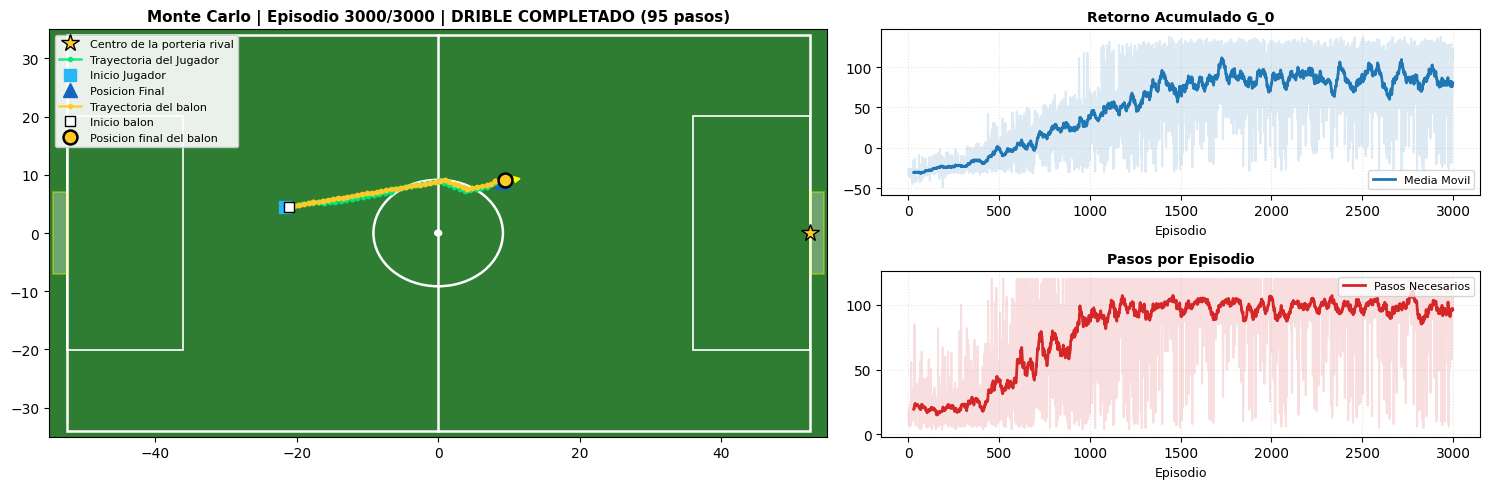

In [76]:
env_live = BallDribblingSimEnv()
Q_live, r_live, l_live = train_visual(
    env_live, "mc", n_episodes=3000, render_every=500, eps_flag=1
)

## 2.2. Implementación de SARSA (On-Policy)


In [77]:
def train_sarsa(env, n_episodes=3500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """Entrena SARSA on-policy y devuelve Q, recompensas y pasos por episodio."""
    n_actions = 4
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    history_rewards = []
    history_lengths = []

    for _ in range(n_episodes):
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, n_actions, epsilon)
        total_return = 0.0
        steps = 0

        while True:
            next_state, reward, done, _ = env.step(action)
            total_return += reward
            steps += 1

            if done:
                td_target = reward
            else:
                next_action = epsilon_greedy_policy(Q, next_state, n_actions, epsilon)
                td_target = reward + gamma * Q[next_state][next_action]

            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error
            if done:
                break
            state, action = next_state, next_action

        history_rewards.append(total_return)
        history_lengths.append(steps)

    return Q, history_rewards, history_lengths

## 2.3. Visualizar SARSA


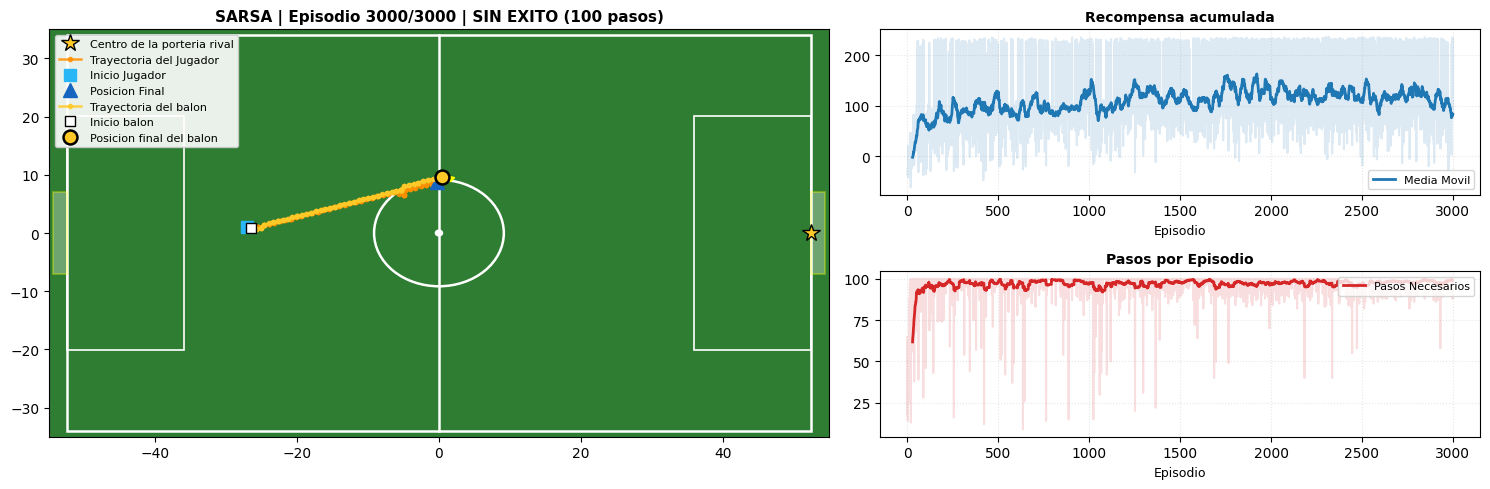

In [38]:
env_sarsa_live = BallDribblingSimEnv()
Q_sarsa_live, r_sarsa_live, l_sarsa_live = train_visual(
    env_sarsa_live, "sarsa", n_episodes=3000, render_every=500
)

## 2.4. Expected SARSA


In [78]:
def train_expected_sarsa(env, n_episodes=3500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """Entrena Expected SARSA y devuelve Q, recompensas y pasos por episodio."""
    n_actions = 4
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    history_rewards, history_lengths = [], []

    for _ in range(n_episodes):
        state = env.reset()
        total_reward = 0.0
        steps = 0

        while True:
            action = epsilon_greedy_policy(Q, state, n_actions, epsilon)
            next_state, reward, done, _ = env.step(action)
            total_reward += reward
            steps += 1

            if done:
                target = reward
            else:
                next_q = Q[next_state]
                expected_q = epsilon * next_q.mean() + (1 - epsilon) * next_q.max()
                target = reward + gamma * expected_q

            Q[state][action] += alpha * (target - Q[state][action])
            if done:
                break
            state = next_state

        history_rewards.append(total_reward)
        history_lengths.append(steps)

    return Q, history_rewards, history_lengths

## 2.5. Visualizar Expected SARSA


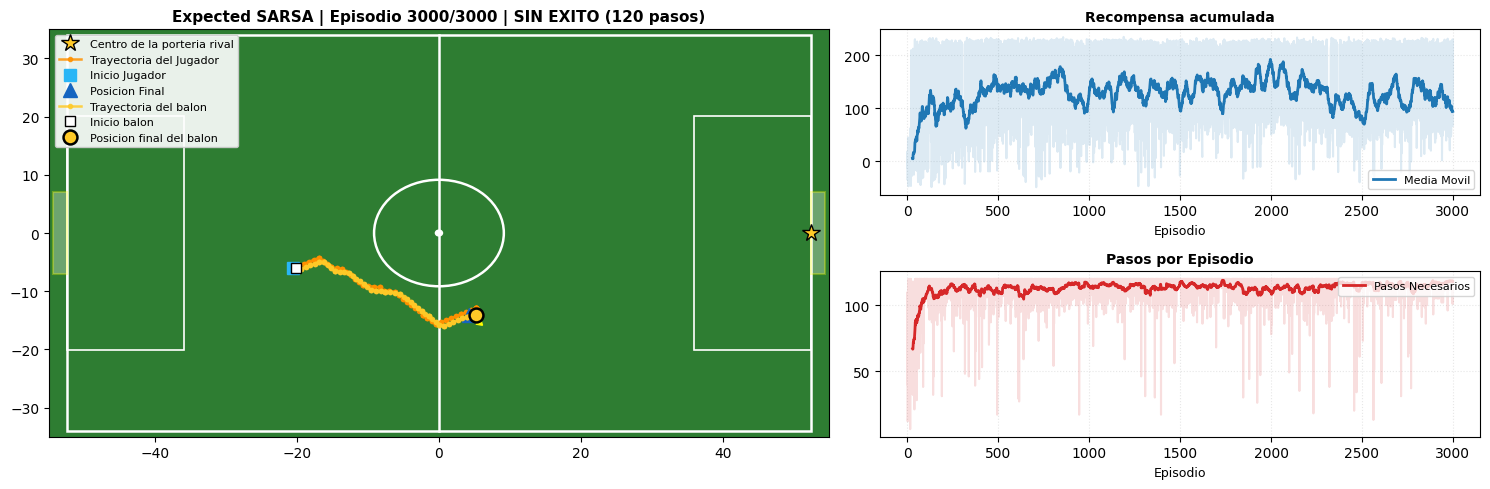

In [79]:
env_expected_live = BallDribblingSimEnv()
Q_expected_live, r_expected_live, l_expected_live = train_visual(
    env_expected_live, "expected_sarsa", n_episodes=3000, render_every=500
)

## 2.6. Q-Learning (Off-Policy)


In [80]:
def train_q_learning(env, n_episodes=3500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """Entrena Q-Learning y devuelve Q, recompensas y pasos por episodio."""
    n_actions = 4
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    history_rewards, history_lengths = [], []

    for _ in range(n_episodes):
        state = env.reset()
        total_reward = 0.0
        steps = 0

        while True:
            action = epsilon_greedy_policy(Q, state, n_actions, epsilon)
            next_state, reward, done, _ = env.step(action)
            total_reward += reward
            steps += 1

            target = reward if done else reward + gamma * Q[next_state].max()
            Q[state][action] += alpha * (target - Q[state][action])
            if done:
                break
            state = next_state

        history_rewards.append(total_reward)
        history_lengths.append(steps)

    return Q, history_rewards, history_lengths

## 2.7. Visualizar Q-Learning


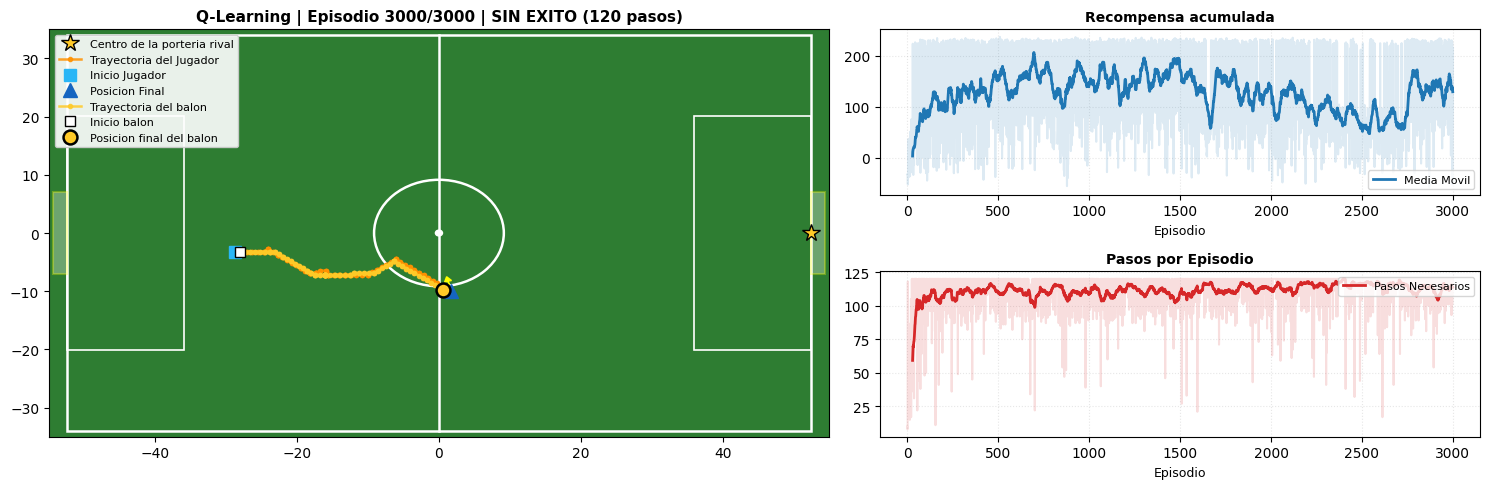

In [83]:
env_q_learning_live = BallDribblingSimEnv()
Q_q_learning_live, r_q_learning_live, l_q_learning_live = train_visual(
    env_q_learning_live, "q_learning", n_episodes=3000, render_every=500
)

## 2.9. Comparación Varianza y Bias


In [82]:
def plot_mc_td_bias_variance(
    n_episodes=3000,
    checkpoint_every=25,
    n_probe=300,
    n_reference=2000,
    gamma=0.99,
    alpha=0.1,
    epsilon=0.1,
    seed=42,
):
    """Compara el sesgo y la varianza de los objetivos de cuatro algoritmos."""
    if n_probe < 2 or n_reference < 2 or checkpoint_every < 1:
        raise ValueError("Se requieren al menos 2 muestras y checkpoints válidos")

    rng = np.random.default_rng(seed)
    env = BallDribblingSimEnv()

    def start_at(distance):
        # Variar la distancia dentro del mismo estado discretizado de control.
        env.player_x, env.player_y, env.player_theta = -25.0, 0.0, 0.0
        env.ball_x, env.ball_y = env.player_x + distance, 0.0
        env.ball_start_x = env.ball_x
        env.steps = 0
        env.player_trajectory_x = [env.player_x]
        env.player_trajectory_y = [env.player_y]
        env.ball_trajectory_x = [env.ball_x]
        env.ball_trajectory_y = [env.ball_y]
        return env._get_state()

    def greedy_action(state):
        # Patear con control; acercarse cuando el balón queda fuera del radio de pateo.
        return 0 if state[0] == 0 else 1

    def policy(state):
        return int(rng.integers(4)) if rng.random() < epsilon else greedy_action(state)

    def mc_return(distance):
        start_at(distance)
        action = 0
        total, discount = 0.0, 1.0
        while True:
            next_state, reward, done, _ = env.step(action)
            total += discount * reward
            if done:
                return total
            discount *= gamma
            action = policy(next_state)

    # Todos los inicios pertenecen al mismo estado discretizado de control.
    reference_distances = rng.uniform(0.4, 0.7, size=n_reference)
    probe_distances = rng.uniform(0.4, 0.7, size=n_probe)
    # MC, SARSA y Expected SARSA evalúan la misma política fija con exploración.
    policy_reference = np.mean(
        [mc_return(distance) for distance in reference_distances]
    )

    # Referencia de la política sin exploración para Q-Learning.
    baseline_returns = []
    for distance in reference_distances:
        state = start_at(distance)
        total, discount = 0.0, 1.0
        while True:
            next_state, reward, done, _ = env.step(greedy_action(state))
            total += discount * reward
            if done:
                break
            discount *= gamma
            state = next_state
        baseline_returns.append(total)
    baseline_reference = np.mean(baseline_returns)

    names = ("MC", "SARSA", "Expected SARSA", "Q-Learning")
    Q = {
        name: defaultdict(lambda: np.zeros(4, dtype=np.float64))
        for name in names
        if name != "MC"
    }
    bias = {name: [] for name in names}
    variance = {name: [] for name in names}
    error = {name: [] for name in names}
    episodes = []

    def measure(episode):
        targets = {name: np.empty(n_probe) for name in names}
        targets["MC"][:] = [mc_return(distance) for distance in probe_distances]

        for i, distance in enumerate(probe_distances):
            start_at(distance)
            next_state, reward, done, _ = env.step(0)
            if done:
                for name in names[1:]:
                    targets[name][i] = reward
                continue

            next_action = policy(next_state)
            targets["SARSA"][i] = reward + gamma * Q["SARSA"][next_state][next_action]
            next_q = Q["Expected SARSA"][next_state]
            expected_q = (
                epsilon * next_q.mean()
                + (1 - epsilon) * next_q[greedy_action(next_state)]
            )
            targets["Expected SARSA"][i] = reward + gamma * expected_q
            targets["Q-Learning"][i] = (
                reward + gamma * Q["Q-Learning"][next_state].max()
            )

        episodes.append(episode)
        for name in names:
            reference = baseline_reference if name == "Q-Learning" else policy_reference
            values = targets[name]
            bias[name].append(values.mean() - reference)
            variance[name].append(values.var(ddof=1))
            error[name].append(1.96 * values.std(ddof=1) / np.sqrt(n_probe))

    measure(0)

    for episode in range(1, n_episodes + 1):
        state = start_at(rng.uniform(0.4, 0.7))
        action = policy(state)
        while True:
            next_state, reward, done, _ = env.step(action)
            if done:
                targets = {name: reward for name in Q}
            else:
                next_action = policy(next_state)
                next_q = Q["Expected SARSA"][next_state]
                expected_q = (
                    epsilon * next_q.mean()
                    + (1 - epsilon) * next_q[greedy_action(next_state)]
                )
                targets = {
                    "SARSA": reward + gamma * Q["SARSA"][next_state][next_action],
                    "Expected SARSA": reward + gamma * expected_q,
                    "Q-Learning": reward + gamma * Q["Q-Learning"][next_state].max(),
                }

            for name in Q:
                Q[name][state][action] += alpha * (
                    targets[name] - Q[name][state][action]
                )
            if done:
                break
            state, action = next_state, next_action

        if episode % checkpoint_every == 0 or episode == n_episodes:
            measure(episode)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    colors = {
        "MC": "#1f77b4",
        "SARSA": "#d62728",
        "Expected SARSA": "#2ca02c",
        "Q-Learning": "#9467bd",
    }
    for name in names:
        values = np.asarray(bias[name])
        band = np.asarray(error[name])
        axes[0].plot(episodes, values, label=name, color=colors[name])
        axes[0].fill_between(
            episodes, values - band, values + band, color=colors[name], alpha=0.12
        )
        axes[1].plot(episodes, variance[name], label=name, color=colors[name])

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Sesgo empírico del objetivo")
    axes[0].set_ylabel("Objetivo medio − referencia")
    axes[1].set_title("Varianza entre muestras del mismo estado discretizado")
    axes[1].set_ylabel("Varianza entre muestras (escala log)")
    axes[1].set_yscale("symlog", linthresh=1)
    axes[1].set_ylim(bottom=0)
    for ax in axes:
        ax.set_xlabel("Episodios de entrenamiento")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.suptitle(
        "MC / SARSA / Expected SARSA: referencia de política fija; "
        "Q-Learning: referencia sin exploración"
    )
    fig.tight_layout()
    plt.show()

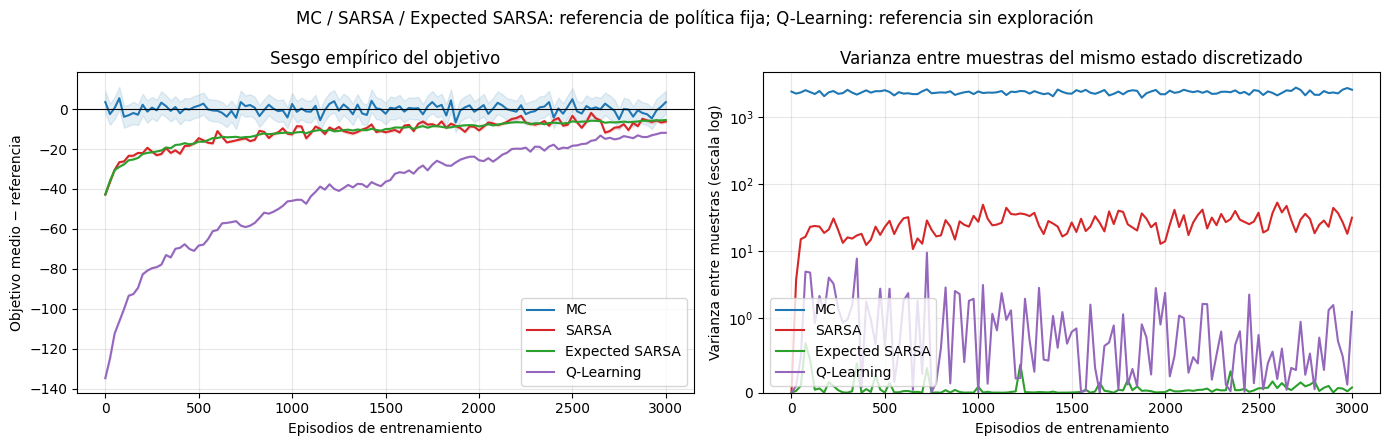

In [84]:
plot_mc_td_bias_variance()

## 3. Evaluación y análisis de curvas de aprendizaje

Se comparan los cuatro algoritmos mediante el retorno o recompensa por episodio y su duración, suavizados con una media móvil de 50 episodios.


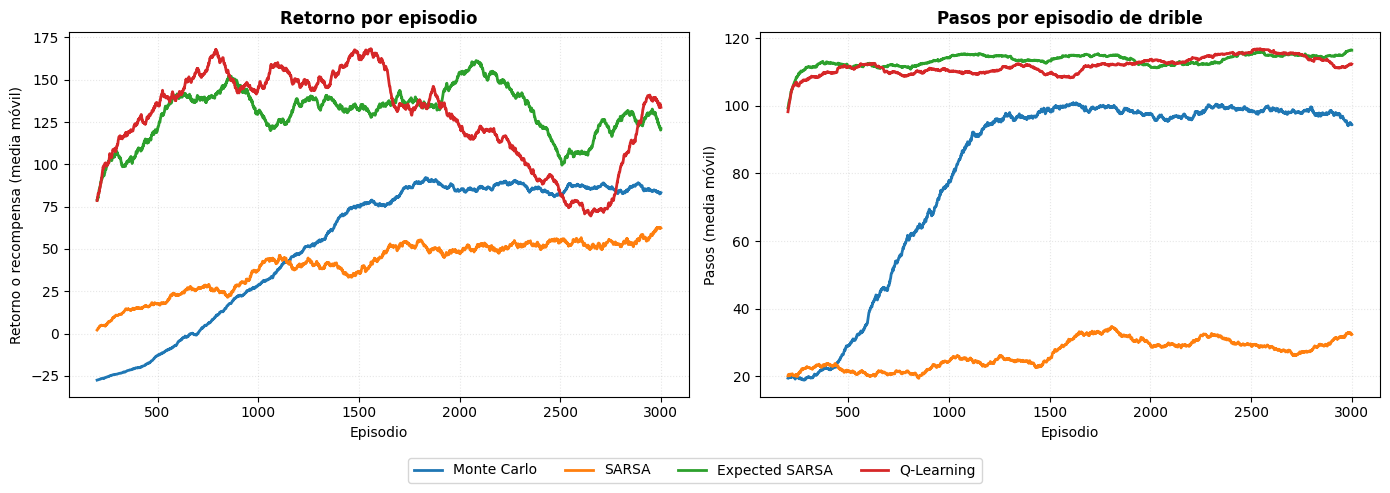

In [86]:
# Curvas de aprendizaje de los cuatro algoritmos (media movil de 50 episodios)
series = [
    ("Monte Carlo", r_live, l_live, "#1f77b4", "-"),
    ("SARSA", r_sarsa_live, l_sarsa_live, "#ff7f0e", "-"),
    ("Expected SARSA", r_expected_live, l_expected_live, "#2ca02c", "-"),
    ("Q-Learning", r_q_learning_live, l_q_learning_live, "#d62728", "-"),
]
window = 200
fig, (ax_reward, ax_steps) = plt.subplots(1, 2, figsize=(14, 5))

for name, rewards, lengths, color, style in series:
    for ax, values in ((ax_reward, rewards), (ax_steps, lengths)):
        moving_avg = np.convolve(values, np.ones(window) / window, mode="valid")
        episodes = np.arange(window, len(values) + 1)
        ax.plot(
            episodes, moving_avg, label=name, color=color, linestyle=style, linewidth=2
        )

ax_reward.set_title("Retorno por episodio", fontweight="bold")
ax_reward.set_ylabel("Retorno o recompensa (media móvil)")
ax_steps.set_title("Pasos por episodio de drible", fontweight="bold")
ax_steps.set_ylabel("Pasos (media móvil)")
for ax in (ax_reward, ax_steps):
    ax.set_xlabel("Episodio")
    ax.grid(True, alpha=0.3, linestyle=":")

fig.legend(
    *ax_reward.get_legend_handles_labels(),
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.01)
)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

## 4. Tablas Q, funciones de valor y políticas aprendidas

Se muestran las cuatro acciones de cada algoritmo para estados de distancia y ángulo del balón, con la portería a 60-70 m y alineada al frente. El resumen muestra la acción greedy y el valor máximo en ese mismo contexto.


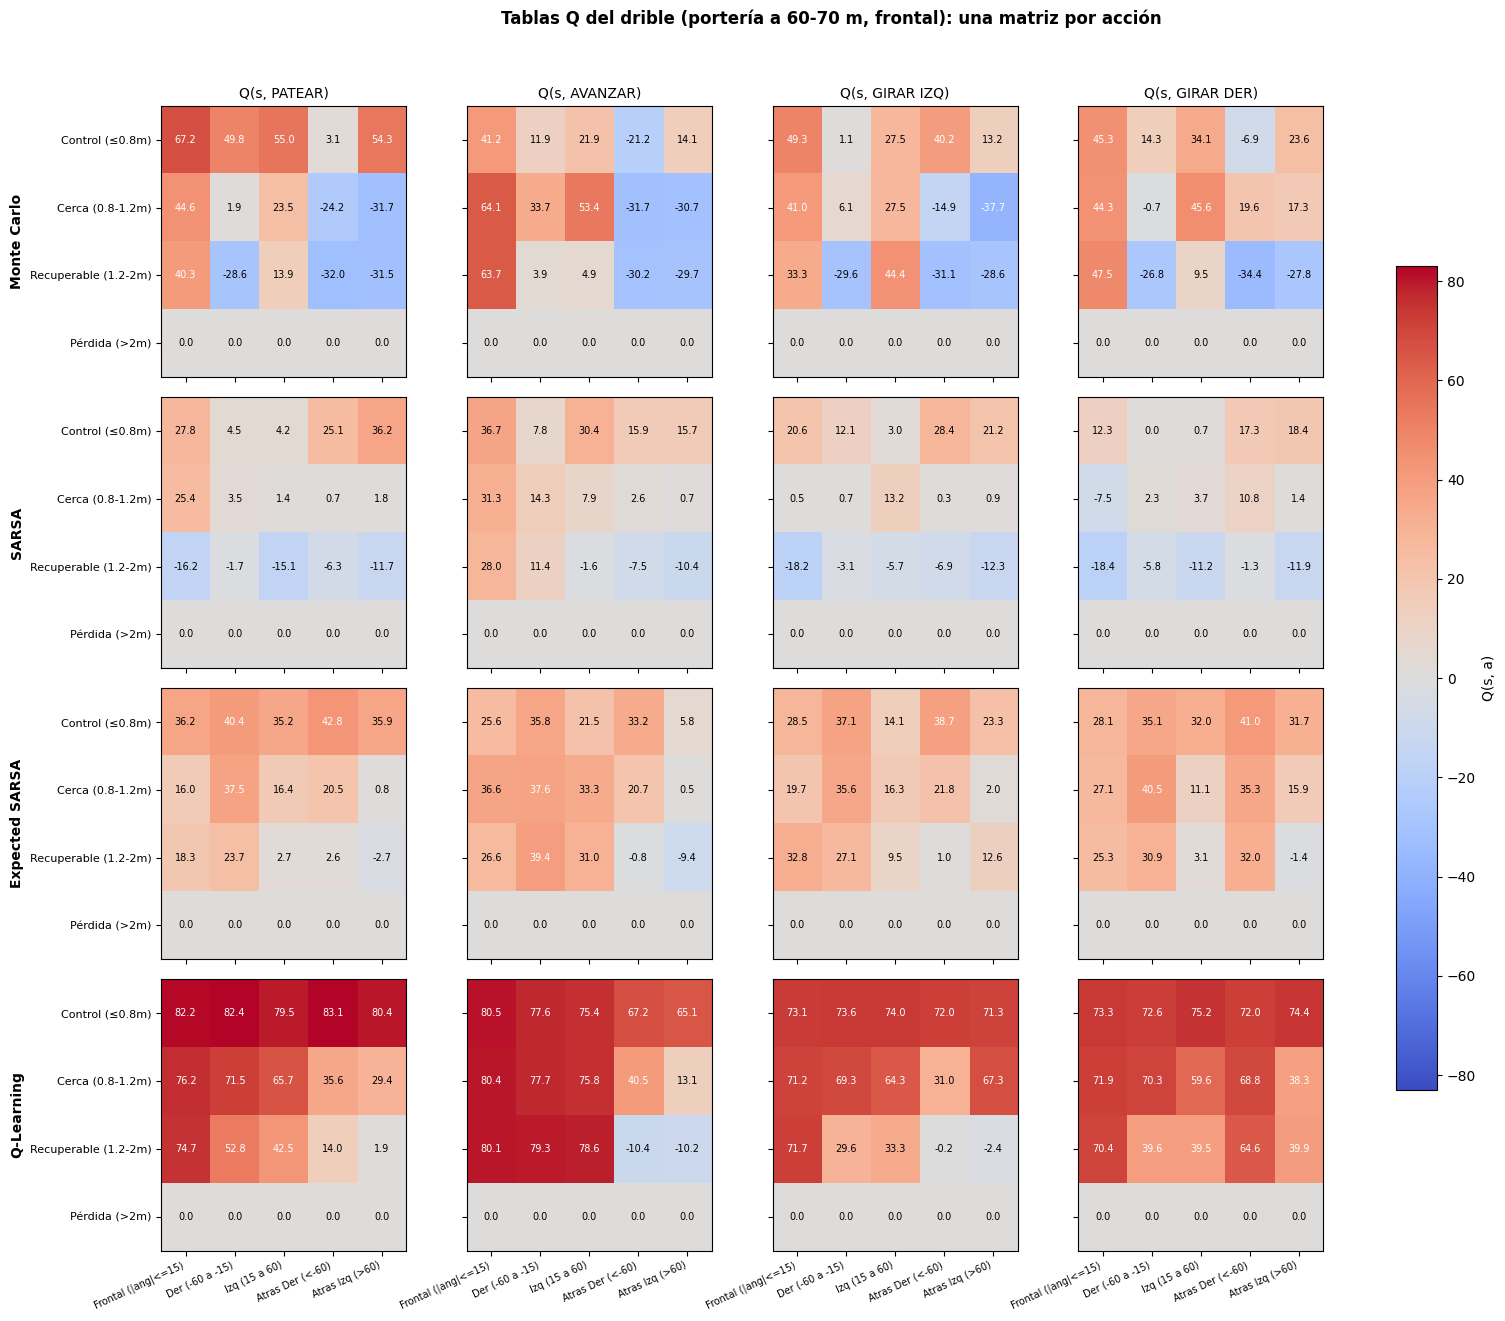

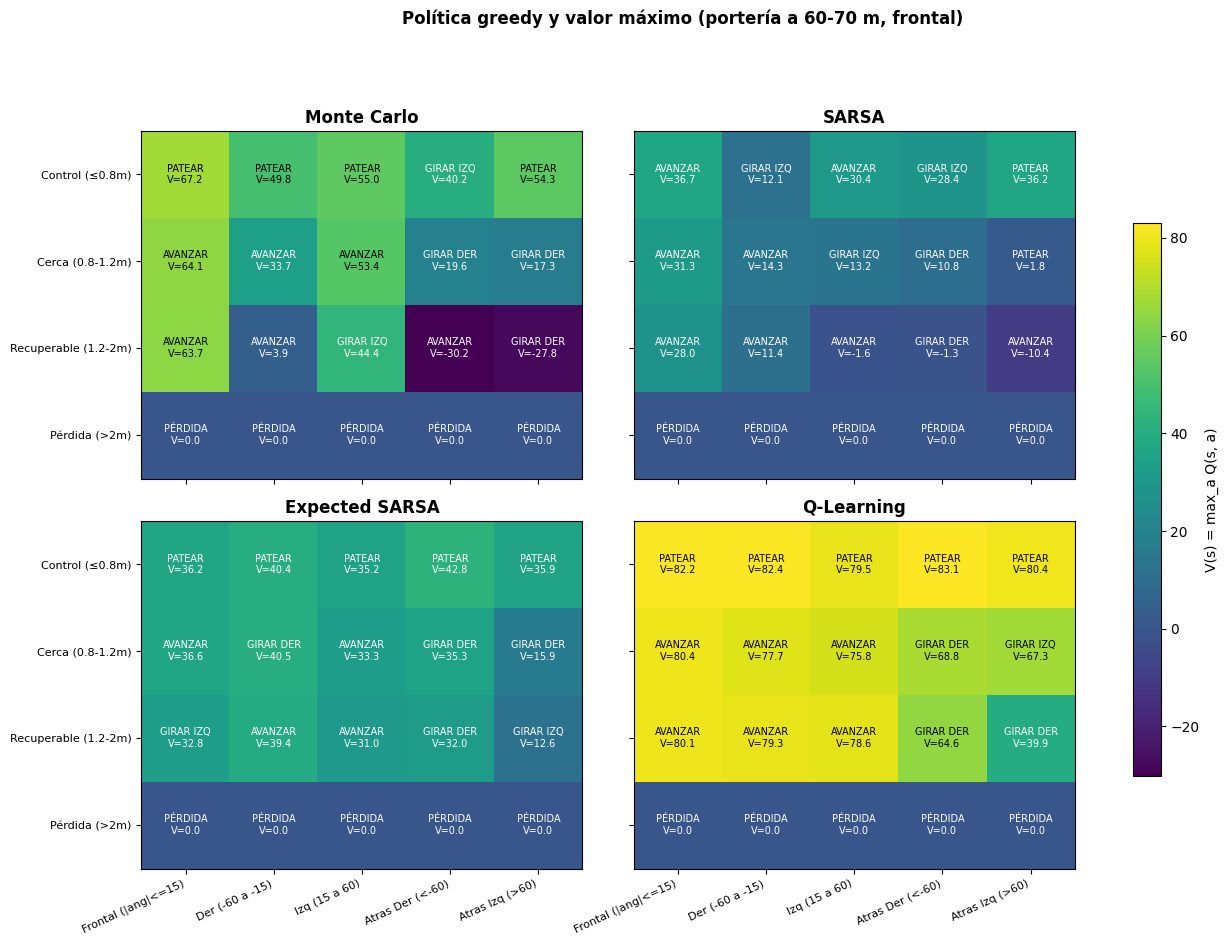

In [ ]:
# Q(s, a) para las cuatro acciones y un contexto fijo de portería.
dist_labels = [
    "Control (≤0.8m)",
    "Cerca (0.8-1.2m)",
    "Recuperable (1.2-2m)",
    "Pérdida (>2m)",
]
angle_labels = [
    "Frontal (|ang|<=15)",
    "Der (-60 a -15)",
    "Izq (15 a 60)",
    "Atras Der (<-60)",
    "Atras Izq (>60)",
]
action_names = ["PATEAR", "AVANZAR", "GIRAR IZQ", "GIRAR DER"]
algorithms = [
    ("Monte Carlo", Q_live),
    ("SARSA", Q_sarsa_live),
    ("Expected SARSA", Q_expected_live),
    ("Q-Learning", Q_q_learning_live),
]

# Corte de la tabla Q: portería a 60-70 m y alineada al frente.
goal_dist_bin, goal_angle_bin = 2, 0
q_tables = []
for name, table in algorithms:
    q_grid = np.zeros((len(dist_labels), len(angle_labels), len(action_names)))
    for d_idx in range(len(dist_labels)):
        for a_idx in range(len(angle_labels)):
            q_grid[d_idx, a_idx] = table.get(
                (d_idx, a_idx, goal_dist_bin, goal_angle_bin),
                np.zeros(len(action_names)),
            )
    q_tables.append((name, q_grid))

q_limit = max(float(np.max(np.abs(grid))) for _, grid in q_tables) or 1.0
fig_q, axes_q = plt.subplots(4, 4, figsize=(19, 14), sharex=True, sharey=True)
for row, (name, q_grid) in enumerate(q_tables):
    for action_idx, action_name in enumerate(action_names):
        ax = axes_q[row, action_idx]
        image_q = ax.imshow(
            q_grid[:, :, action_idx],
            cmap="coolwarm",
            vmin=-q_limit,
            vmax=q_limit,
            aspect="auto",
        )
        if row == 0:
            ax.set_title(f"Q(s, {action_name})", fontsize=10)
        ax.set_xticks(range(len(angle_labels)))
        ax.set_xticklabels(
            angle_labels if row == 3 else [], rotation=25, ha="right", fontsize=7
        )
        ax.set_yticks(range(len(dist_labels)))
        if action_idx == 0:
            ax.set_yticklabels(dist_labels, fontsize=8)
        else:
            ax.tick_params(axis="y", labelleft=False)
        if action_idx == 0:
            ax.set_ylabel(name, fontweight="bold")
        for d_idx in range(len(dist_labels)):
            for a_idx in range(len(angle_labels)):
                value = q_grid[d_idx, a_idx, action_idx]
                text_color = "white" if abs(value) > 0.45 * q_limit else "black"
                ax.text(
                    a_idx,
                    d_idx,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=text_color,
                )

fig_q.suptitle(
    "Tablas Q del drible (portería a 60-70 m, frontal): una matriz por acción",
    fontweight="bold",
)
fig_q.tight_layout(rect=(0.06, 0.04, 0.92, 0.96))
fig_q.colorbar(image_q, ax=axes_q.ravel().tolist(), shrink=0.72, label="Q(s, a)")
plt.show()

# Resumen comparable: color = mejor valor Q; texto = acción greedy y su valor.
value_grids = [grid.max(axis=2) for _, grid in q_tables]
value_min = min(float(values.min()) for values in value_grids)
value_max = max(float(values.max()) for values in value_grids)
if value_min == value_max:
    value_max = value_min + 1.0
fig_summary, axes_summary = plt.subplots(
    2, 2, figsize=(16, 10), sharex=True, sharey=True
)
for ax, (name, q_grid), values in zip(axes_summary.flat, q_tables, value_grids):
    policy_grid = q_grid.argmax(axis=2)
    image_summary = ax.imshow(
        values, cmap="viridis", vmin=value_min, vmax=value_max, aspect="auto"
    )
    ax.set_title(name, fontweight="bold")
    ax.set_xticks(range(len(angle_labels)))
    ax.set_xticklabels(angle_labels, rotation=25, ha="right", fontsize=8)
    ax.set_yticks(range(len(dist_labels)))
    ax.set_yticklabels(dist_labels, fontsize=8)
    for d_idx in range(len(dist_labels)):
        for a_idx in range(len(angle_labels)):
            action = (
                "PÉRDIDA" if d_idx == 3 else action_names[policy_grid[d_idx, a_idx]]
            )
            relative_value = (values[d_idx, a_idx] - value_min) / (
                value_max - value_min
            )
            text_color = "black" if relative_value > 0.68 else "white"
            ax.text(
                a_idx,
                d_idx,
                f"{action}\nV={values[d_idx, a_idx]:.1f}",
                ha="center",
                va="center",
                fontsize=7,
                color=text_color,
            )

fig_summary.suptitle(
    "Política greedy y valor máximo (portería a 60-70 m, frontal)", fontweight="bold"
)
fig_summary.tight_layout(rect=(0.07, 0.04, 0.90, 0.93))
fig_summary.colorbar(
    image_summary,
    ax=axes_summary.ravel().tolist(),
    shrink=0.75,
    label="V(s) = max_a Q(s, a)",
)
plt.show()

## 5. Visualización de trayectorias sobre la cancha

Se comparan un paseo aleatorio y un episodio con la política greedy aprendida. Los dos parten de la misma posición y buscan el mismo balón. La figura indica si hubo captura; si la política solo gira, su trayectoria espacial se reduce al punto de partida.

Si la imagen guardada todavía muestra el bucle anterior, vuelve a ejecutar el notebook desde la sección 2 para recalcular `Q_opt` y actualizar las gráficas.


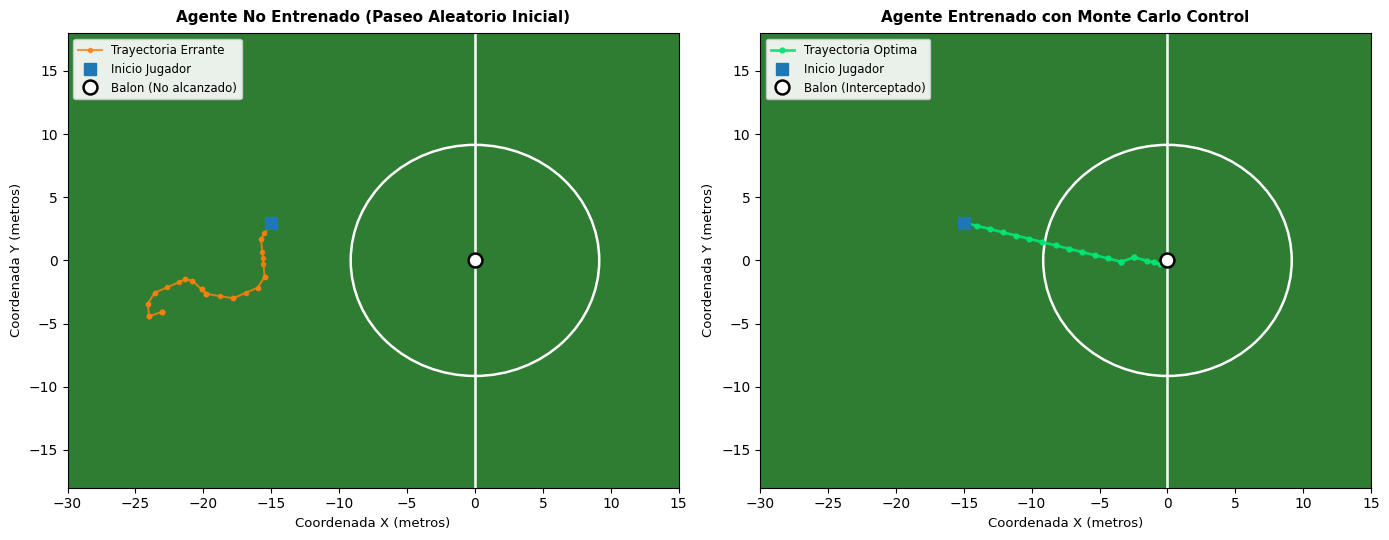

MC: 16 DASH, 5 TURN, distancia final 0.61 m, captura: True


In [ ]:
# 1. Simular trayectoria de un agente no entrenado (acciones puramente aleatorias)
env_eval = BallDribblingSimEnv()
env_eval.reset()
env_eval.player_x, env_eval.player_y, env_eval.player_theta = -15.0, 3.0, -120.0
env_eval.ball_x, env_eval.ball_y = 0.0, 0.0
env_eval.trajectory_x = [env_eval.player_x]
env_eval.trajectory_y = [env_eval.player_y]
ball_pos_untrained = (env_eval.ball_x, env_eval.ball_y)

for _ in range(env_eval.max_steps):
    action = np.random.randint(4)
    _, _, done, _ = env_eval.step(action)
    if done:
        break
trajectory_untrained_player = (list(env_eval.trajectory_x), list(env_eval.trajectory_y))

# 2. Simular trayectoria del agente entrenado con Monte Carlo Control (politica greedy)
env_eval.reset()
env_eval.player_x, env_eval.player_y, env_eval.player_theta = -15.0, 3.0, -120.0
env_eval.ball_x, env_eval.ball_y = 0.0, 0.0
env_eval.trajectory_x = [env_eval.player_x]
env_eval.trajectory_y = [env_eval.player_y]
ball_pos_trained = (env_eval.ball_x, env_eval.ball_y)
state = env_eval._get_state()
trained_actions = []

for _ in range(env_eval.max_steps):
    action = int(np.argmax(Q_opt[state]))
    trained_actions.append(action)
    state, _, done, _ = env_eval.step(action)
    if done:
        break
trajectory_trained_player = (list(env_eval.trajectory_x), list(env_eval.trajectory_y))
trained_success = env_eval._get_obs()[0] < 0.8


# 3. Dibujar la cancha oficial y comparar visualmente ambas trayectorias
def draw_pitch(ax, title):
    ax.set_facecolor("#2e7d32")
    pitch_border = patches.Rectangle(
        (-52.5, -34), 105, 68, linewidth=1.8, edgecolor="white", facecolor="none"
    )
    half_line = plt.Line2D([0, 0], [-34, 34], color="white", linewidth=1.8)
    center_circle = patches.Circle(
        (0, 0), 9.15, linewidth=1.8, edgecolor="white", facecolor="none"
    )
    center_spot = patches.Circle((0, 0), 0.5, color="white")
    left_box = patches.Rectangle(
        (-52.5, -20.16), 16.5, 40.32, linewidth=1.2, edgecolor="white", facecolor="none"
    )
    right_box = patches.Rectangle(
        (36.0, -20.16), 16.5, 40.32, linewidth=1.2, edgecolor="white", facecolor="none"
    )
    left_goal = patches.Rectangle(
        (-54.5, -7.0),
        2.0,
        14.0,
        linewidth=1.5,
        edgecolor="yellow",
        facecolor="#ffffff",
        alpha=0.3,
    )
    right_goal = patches.Rectangle(
        (52.5, -7.0),
        2.0,
        14.0,
        linewidth=1.5,
        edgecolor="yellow",
        facecolor="#ffffff",
        alpha=0.3,
    )

    ax.add_patch(pitch_border)
    ax.add_line(half_line)
    ax.add_patch(center_circle)
    ax.add_patch(center_spot)
    ax.add_patch(left_box)
    ax.add_patch(right_box)
    ax.add_patch(left_goal)
    ax.add_patch(right_goal)

    ax.set_xlim(-30, 15)
    ax.set_ylim(-18, 18)
    ax.set_xlabel("Coordenada X (metros)", fontsize=9.5)
    ax.set_ylabel("Coordenada Y (metros)", fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)


fig_traj, (ax_t1, ax_t2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: No entrenado
draw_pitch(ax_t1, "Agente No Entrenado (Paseo Aleatorio Inicial)")
ax_t1.plot(
    trajectory_untrained_player[0],
    trajectory_untrained_player[1],
    "-o",
    color="#ff7f0e",
    markersize=3,
    linewidth=1.5,
    alpha=0.8,
    label="Trayectoria Errante",
)
ax_t1.plot(
    trajectory_untrained_player[0][0],
    trajectory_untrained_player[1][0],
    "s",
    markersize=9,
    color="#1f77b4",
    label="Inicio Jugador",
)
ax_t1.plot(
    ball_pos_untrained[0],
    ball_pos_untrained[1],
    "o",
    markersize=10,
    color="white",
    markeredgecolor="black",
    markeredgewidth=1.8,
    label="Balon (No alcanzado)",
)
ax_t1.legend(loc="upper left", fontsize=8.5, framealpha=0.9)

# Subplot 2: Entrenado con MC Control
draw_pitch(ax_t2, "Agente Entrenado con Monte Carlo Control")
ax_t2.plot(
    trajectory_trained_player[0],
    trajectory_trained_player[1],
    "-o",
    color="#00e676",
    markersize=3.5,
    linewidth=2.0,
    alpha=0.9,
    label="Trayectoria Optima",
)
ax_t2.plot(
    trajectory_trained_player[0][0],
    trajectory_trained_player[1][0],
    "s",
    markersize=9,
    color="#1f77b4",
    label="Inicio Jugador",
)
ax_t2.plot(
    ball_pos_trained[0],
    ball_pos_trained[1],
    "o",
    markersize=10,
    color="white",
    markeredgecolor="black",
    markeredgewidth=1.8,
    label="Balon (Interceptado)" if trained_success else "Balon (No alcanzado)",
)
if not any(action in (0, 1) for action in trained_actions):
    ax_t2.text(
        -14,
        7,
        "Solo giró: no hubo desplazamiento",
        color="white",
        bbox={"facecolor": "#1b5e20", "alpha": 0.9, "edgecolor": "none"},
    )
ax_t2.legend(loc="upper left", fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.show()
print(
    f"MC: {sum(action in (0, 1) for action in trained_actions)} DASH, "
    f"{sum(action in (2, 3) for action in trained_actions)} TURN, "
    f"distancia final {env_eval._get_obs()[0]:.2f} m, "
    f"captura: {trained_success}"
)

## 5.1 Simulacion y animacion paso a paso del drible

Esta visualizacion ejecuta una politica tabular en `BallDribblingSimEnv`. En cada paso muestra las trayectorias del jugador y del balon, su separacion, el avance horizontal del balon y la accion elegida. La linea discontinua marca el avance requerido desde la posicion inicial del balon; la estrella marca la porteria rival. El episodio termina segun las reglas del entorno, no al tocar el balon.


In [ ]:
def animar_partido_paso_a_paso(
    env,
    Q_opt,
    max_steps=None,
    delay=0.06,
    nombre="Politica",
):
    """Anima una politica de drible con el jugador y el balon en movimiento."""
    state = env.reset()
    steps_to_show = (
        env.max_steps if max_steps is None else min(max_steps, env.max_steps)
    )
    if steps_to_show < 1 or delay < 0:
        raise ValueError("max_steps debe ser positivo y delay no negativo")

    action_names = ["KICK 25", "DASH 80", "TURN +35", "TURN -35"]
    done = False
    frame_handle = None
    for step in range(steps_to_show):
        action = int(np.argmax(Q_opt[state]))
        state, reward, done, info = env.step(action)

        outside = (
            abs(env.player_x) > 52.5
            or abs(env.player_y) > 34.0
            or abs(env.ball_x) > 52.5
            or abs(env.ball_y) > 34.0
        )
        if info["success"]:
            status = "OBJETIVO CUMPLIDO"
        elif outside:
            status = "FUERA DE LA CANCHA"
        elif not info["possession"]:
            status = "POSESION PERDIDA"
        elif done:
            status = "LIMITE DE PASOS"
        else:
            status = "EN CURSO"

        fig, ax = plt.subplots(figsize=(12, 7))
        ax.set_facecolor("#2e7d32")
        ax.add_patch(
            patches.Rectangle(
                (-52.5, -34),
                105,
                68,
                linewidth=2,
                edgecolor="white",
                facecolor="none",
            )
        )
        ax.plot([0, 0], [-34, 34], color="white", linewidth=2)
        ax.add_patch(
            patches.Circle(
                (0, 0),
                9.15,
                linewidth=2,
                edgecolor="white",
                facecolor="none",
            )
        )
        ax.add_patch(patches.Circle((0, 0), 0.5, color="white"))
        for box_x in (-52.5, 36.0):
            ax.add_patch(
                patches.Rectangle(
                    (box_x, -20.16),
                    16.5,
                    40.32,
                    linewidth=1.5,
                    edgecolor="white",
                    facecolor="none",
                )
            )
        ax.add_patch(
            patches.Rectangle(
                (52.5, -7.0),
                2.0,
                14.0,
                linewidth=1.5,
                edgecolor="yellow",
                facecolor="none",
            )
        )
        ax.plot(
            env.goal_x,
            env.goal_y,
            "*",
            markersize=14,
            color="#ffca28",
            markeredgecolor="black",
            label="Porteria rival",
        )
        target_x = env.ball_start_x + env.target_distance
        if -52.5 <= target_x <= 52.5:
            ax.axvline(
                target_x,
                color="#ffca28",
                linestyle="--",
                alpha=0.8,
                label="Avance objetivo",
            )

        ax.plot(
            env.player_trajectory_x,
            env.player_trajectory_y,
            color="#00e676",
            linewidth=2,
            label="Trayectoria jugador",
        )
        ax.plot(
            env.ball_trajectory_x,
            env.ball_trajectory_y,
            color="#ff9100",
            linewidth=2,
            marker="o",
            markersize=2,
            label="Trayectoria balon",
        )
        ax.plot(
            env.player_trajectory_x[0],
            env.player_trajectory_y[0],
            "s",
            markersize=8,
            color="#29b6f6",
            label="Inicio jugador",
        )
        ax.plot(
            env.ball_trajectory_x[0],
            env.ball_trajectory_y[0],
            "s",
            markersize=8,
            color="white",
            markeredgecolor="black",
            label="Inicio balon",
        )
        ax.plot(
            env.player_x,
            env.player_y,
            "^",
            markersize=11,
            color="#1565c0",
            label="Jugador",
        )
        ax.plot(
            env.ball_x,
            env.ball_y,
            "o",
            markersize=10,
            color="#ffca28",
            markeredgecolor="black",
            label="Balon",
        )
        rad = math.radians(env.player_theta)
        ax.arrow(
            env.player_x,
            env.player_y,
            1.8 * math.cos(rad),
            1.8 * math.sin(rad),
            head_width=1.0,
            head_length=0.8,
            fc="yellow",
            ec="yellow",
        )

        ax.set_xlim(-55, 55)
        ax.set_ylim(-35, 35)
        ax.set_aspect("equal")
        ax.set_xlabel("Coordenada X (m)")
        ax.set_ylabel("Coordenada Y (m)")
        ax.set_title(
            f"{nombre} | Paso {step + 1}/{env.max_steps} | {action_names[action]} | {status}\n"
            f"Avance: {info['progress']:.1f}/{env.target_distance:.1f} m | "
            f"Separacion jugador-balon: {info['ball_dist']:.2f} m",
            fontsize=11,
        )
        ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
        plt.tight_layout()
        if frame_handle is None:
            frame_handle = display(fig, display_id=True)
        else:
            frame_handle.update(fig)
        plt.close(fig)
        if delay:
            time.sleep(delay)
        if done:
            break

    if done:
        print(
            f"{nombre}: {status} en {step + 1} pasos. Avance: {info['progress']:.1f} m."
        )
    else:
        print(
            f"{nombre}: visualizacion detenida tras {steps_to_show} pasos; episodio en curso."
        )

In [ ]:
animar_partido_paso_a_paso(env_train, Q_opt, nombre="Monte Carlo")

animar_partido_paso_a_paso(env_train, Q_sarsa_live, nombre="SARSA")

animar_partido_paso_a_paso(env_train, Q_expected_live, nombre="Expected SARSA")

animar_partido_paso_a_paso(env_train, Q_q_learning_live, nombre="Q-Learning")

## 6. Despliegue en Vivo contra el Servidor RoboCup 2D (rcssserver)

Tras entrenar `Q_opt`, esta celda prepara un episodio en `rcssserver`: coloca al jugador en (-25, 0) y el balon 0.5 m delante, lee balon y porteria rival, discretiza las cuatro variables y envia la accion elegida. Ejecutala en el Jupyter de Docker despues del entrenamiento. La prueba muestra acciones reales; no calcula por si sola la tasa de exito de drible en RoboCup.


In [ ]:
import os
import sys

sys.path.append("/workspace/src")
from robocup_client import RoboCup2DClient
from trainer_client import TrainerClient

host = os.getenv("SERVER_HOST", "rcssserver")
trainer = TrainerClient(host=host, port=int(os.getenv("TRAINER_PORT", "6001")))
client = RoboCup2DClient(
    host=host, port=int(os.getenv("SERVER_PORT", "6000")), team_name="UTEC_Drib"
)
action_names = ("KICK 25", "DASH 80", "TURN +35", "TURN -35")

try:
    trainer.connect()
    trainer.change_mode("before_kick_off")
    time.sleep(0.2)
    if not client.connect(init_pos=(-25.0, 0.0)):
        raise RuntimeError("No se pudo conectar el jugador a rcssserver")
    trainer.change_mode("play_on")
    time.sleep(0.2)
    player_x = -25.0 if client.side == "l" else 25.0
    forward = 1 if client.side == "l" else -1
    trainer.send_command(
        f"(move (player {client.team_name} {client.uniform_number}) {player_x} 0 {0 if forward == 1 else 180})"
    )
    trainer.move_ball(player_x + 0.5 * forward, 0.0)
    time.sleep(0.4)
    initial_obs = client.get_latest_observation()
    if initial_obs["ball"] is None or initial_obs["ball"][0] > 0.8:
        raise RuntimeError(f"Balon fuera del alcance inicial: {initial_obs['ball']}")
    print("Ejecutando la politica de drible durante 60 ciclos visuales...")

    last_time = initial_obs["time"]
    paso = 0
    inicio = time.monotonic()
    while paso < 60 and time.monotonic() - inicio < 30:
        obs = client.get_latest_observation()
        if obs["time"] == 0 or obs["time"] == last_time:
            time.sleep(0.03)
            continue
        last_time = obs["time"]
        ball, goal = obs["ball"], obs["goal_opp"]
        if ball is not None and ball[0] > env_train.lost_threshold:
            print(f"Posesion perdida en el paso {paso}: balon a {ball[0]:.2f} m")
            break
        if ball is None or goal is None:
            client.turn(35.0)  # Buscar una observacion completa
            action_name = "BUSCAR BALON/PORTERIA"
        else:
            state = env_train._discretize(ball[0], ball[1], goal[0], goal[1])
            action = int(np.argmax(Q_opt[state]))
            action_name = action_names[action]
            if action == 0:
                client.kick(power=25.0, direction=0.0)
            elif action == 1:
                client.dash(power=80.0)
            elif action == 2:
                client.turn(moment=35.0)
            else:
                client.turn(moment=-35.0)
        if paso % 10 == 0:
            print(f"Paso {paso:02d} | Balon: {ball} | Meta: {goal} | {action_name}")
        paso += 1
    print(f"Sesion finalizada tras {paso} ciclos visuales.")
finally:
    client.close()
    if trainer.connected:
        trainer.send_command("(bye)")
    trainer.close()